*© 2026 Paul Fergus. Free for student and research use — commercial use is strictly prohibited.*

# Lab 8 — Honest evaluation of an object detector

**Module:** Deep Learning Concepts and Techniques (Computer Vision)  
**Week:** 8  
**Estimated time:** 240 minutes

---

## ⚠ This lab requires you to build your own test set

Unlike every previous lab, **there is no dataset bundled with this one**. The entire point is that you source and annotate a *genuinely independent* set of real wildlife images — a **ground-truth test set** the model has never seen — and evaluate against it honestly. You cannot do honest evaluation on data we hand you; you have to build the truth yourself. Section 2 walks you through it.

You will also need your trained model from **Lab 7** (`runs/african_wildlife/weights/best.pt`) and a CUDA GPU.

## Learning outcomes

By the end of this lab you should be able to:

1. Explain why a test split drawn from the training distribution gives optimistic performance estimates, and why an independent ground-truth set is necessary for honest evaluation.
2. Compute the core detection metrics — IoU matching, true/false positives, false negatives, precision, recall — **from first principles**, not just by reading a library's output.
3. Construct a precision-recall curve by sweeping the confidence threshold, and compute Average Precision (AP) as the area beneath it.
4. Explain why the ROC curve does **not** apply to object detection, and why the precision-recall curve is the correct tool instead.
5. Interpret mAP across a range of IoU thresholds (mAP50 vs mAP50-95) and reason about localisation strictness.
6. Perform error analysis — per-class, per-object-size, and by error type (localisation / classification / background) — to diagnose *where* a model fails.
7. Quantify the uncertainty in a metric using bootstrap confidence intervals, and explain why a single mAP number on a small test set is nearly meaningless without them.

## Prerequisites

- **Lab 6** — you'll reuse the annotation tool to label your test set.
- **Lab 7** — you need the detector you trained, and the metrics it reported.
- The textbook *Applied Deep Learning* (Fergus & Chalmers), Chapter 7.
- Lecture 8: *Evaluating detectors honestly — precision-recall, mean Average Precision, and the trouble with ROC*.

## The thread from last week

Lab 7 ended with a tidy table of metrics — precision, recall, mAP50, mAP50-95 — computed on the `test` split of your dataset. Here's the uncomfortable truth: **those numbers were optimistic.** Your test split was carved from the *same* pool of images as your training data — same scenes, same lighting, same style, often the same photographic session. A model can score well there and still fall apart on genuinely new images. The only way to know how good your model *really* is, is to test it on data drawn independently of training — a **ground-truth set** you build from scratch. That's today.

## Useful references

- [Ultralytics performance-metrics guide](https://docs.ultralytics.com/guides/yolo-performance-metrics/)
- Everingham et al. (2010), *The PASCAL Visual Object Classes (VOC) Challenge* — the origin of mAP as used today.
- Padilla et al. (2020), *A Survey on Performance Metrics for Object-Detection Algorithms*.

---

## 1. Why a separate ground-truth set matters

Three terms it pays to be precise about:

- **In-distribution test data** — held-out images that nonetheless come from the same source/distribution as training. Useful during development, but flattering.
- **Out-of-distribution (OOD) test data** — images from a genuinely different source: a different camera, season, location, time of day, photographer. This is what real deployment looks like.
- **Ground truth** — the hand-verified correct answer. For detection, that means *you* drawing the boxes you consider correct, against which the model's predictions are scored.

The gap between in-distribution and OOD performance is called the **generalisation gap** (or, more bluntly, the *train/deploy gap*). It is the single most common reason a model that 'worked in the lab' fails in production. A wildlife detector trained on clean daytime photos will struggle on night camera-trap footage; a model trained on savanna elephants may fail on forest elephants, a visually distinct ecotype. **The only way to measure this gap is to test on data the model has never seen, from a source unlike the training set.**

Today you will build such a set, then measure honestly.

## 2. Build your ground-truth test set

**This is the core practical task. Do it carefully — every metric in this lab is only as trustworthy as the ground truth you build now.**

### Step 2.1 — Source at least 30 real images

Find **at least 30 real photographs** containing the four classes (buffalo, elephant, rhino, zebra). To make the generalisation gap visible, try to source images that differ from your Lab 6/7 training set — different lighting, season, angles, or camera type. Good sources:

- **[iNaturalist](https://www.inaturalist.org/observations)** — filter for CC-licensed observations. Huge, well-labelled by species.
- **[Wikimedia Commons](https://commons.wikimedia.org/)** — search by species, check the licence on each image.
- **[Flickr](https://www.flickr.com/search/)** — filter by Creative Commons licence.
- **Your own photos**, or your institution's camera-trap data if you have access.

**Licensing matters.** Only use images you have the right to use. For a university assignment, CC-licensed or your own images are safest. Keep a note of where each came from.

### Step 2.2 — Put them in place

Drop the JPEGs into this lab's `data/holdout_images/` folder (create it if needed). You can do this from your host machine — the `labs/` folder is bind-mounted.

### Step 2.3 — Annotate them as ground truth

Open the **annotator** from Lab 6 (<http://localhost:8000/annotator>). Annotate every animal in every image, exactly as you did in Lab 6. **Be rigorous and consistent** — this is the *truth* the model is judged against, so sloppy boxes here mean meaningless metrics later.

> **Important — the annotator writes to Lab 6's folders by default.** For this lab, after annotating, copy your images and label `.txt` files into *this* lab's `data/holdout_images/` and `data/holdout_labels/`. Alternatively, point the helper code below at wherever your annotated test images live. The code only needs: a folder of images, and a parallel folder of YOLO `.txt` labels with matching stems.

### Step 2.4 — Tell the notebook where your data is

Set the two paths below to point at your annotated ground-truth set.

In [ ]:
from pathlib import Path

# EDIT THESE to point at your annotated ground-truth test set.
HOLDOUT_IMAGES = Path("data/holdout_images")
HOLDOUT_LABELS = Path("data/holdout_labels")

# Your trained model from Lab 7. We auto-discover the most recently trained
# best.pt — this survives Ultralytics' quirky path nesting (e.g.
# .../detect/runs/<name>/weights/best.pt) and any run-name suffixes from re-training.
_lab7_root = Path("../lab07_yolo_training")
_candidates = sorted(_lab7_root.rglob("weights/best.pt"), key=lambda p: p.stat().st_mtime) if _lab7_root.exists() else []
MODEL_PATH = _candidates[-1].resolve() if _candidates else Path("../lab07_yolo_training/runs/african_wildlife/weights/best.pt")
if _candidates:
    print(f"Using model: {MODEL_PATH}")
    if len(_candidates) > 1:
        print(f"  (picked most recent of {len(_candidates)} runs found)")

# Class list — read from Lab 6's classes.txt so it always matches training order.
_classes_file = Path("../lab06_image_annotation/data/classes.txt")
CLASSES = [ln.strip() for ln in _classes_file.read_text().splitlines() if ln.strip()]

# --- sanity checks ---
image_files = sorted([p for p in HOLDOUT_IMAGES.glob("*.jpg")]) if HOLDOUT_IMAGES.is_dir() else []
n_images = len(image_files)
n_labels = len(list(HOLDOUT_LABELS.glob("*.txt"))) if HOLDOUT_LABELS.is_dir() else 0

print(f"Ground-truth images found: {n_images}")
print(f"Ground-truth label files:  {n_labels}")
print(f"Model checkpoint exists:   {MODEL_PATH.is_file()}")

if n_images == 0:
    print("\n>>> No images found. Complete Section 2 (source + annotate >=30 images) before continuing.")
elif n_images < 30:
    print(f"\n>>> Only {n_images} images. The lab works, but metrics on <30 images are very noisy.")
else:
    print("\nGround-truth set ready.")

## 3. Run the model and collect predictions

We run the trained detector over every held-out image at a **low confidence threshold** (0.001). Why so low? Because to draw a full precision-recall curve we need *every* prediction the model is willing to make, including low-confidence ones — we'll sweep the threshold ourselves later. If we filtered at 0.25 now, we could never see what the curve does below 0.25.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch

assert MODEL_PATH.is_file(), f"Model not found at {MODEL_PATH}. Train it in Lab 7 first."
assert n_images > 0, "No ground-truth images. Complete Section 2 first."
assert torch.cuda.is_available(), "This lab needs a CUDA GPU (see Lab 7)."

model = YOLO(str(MODEL_PATH))

# Predict on every held-out image. conf=0.001 keeps almost everything.
results = model.predict(
    source=[str(p) for p in image_files],
    conf=0.001,
    iou=0.6,         # NMS IoU (for older YOLO); harmless for NMS-free YOLO26
    device=0,
    verbose=False,
)
print(f"Ran model on {len(results)} images.")

# Collect predictions per image into a simple structure:
#   predictions[image_stem] = list of (class_id, score, [x1,y1,x2,y2]) in PIXEL coords
predictions = {}
for r, img_path in zip(results, image_files):
    dets = []
    if r.boxes is not None and len(r.boxes) > 0:
        xyxy = r.boxes.xyxy.cpu().numpy()
        conf = r.boxes.conf.cpu().numpy()
        cls = r.boxes.cls.cpu().numpy().astype(int)
        for i in range(len(xyxy)):
            dets.append((int(cls[i]), float(conf[i]), xyxy[i].tolist()))
    predictions[img_path.stem] = dets

total_preds = sum(len(v) for v in predictions.values())
print(f"Collected {total_preds} raw predictions (before thresholding).")

Ran model on 40 images.
Collected 188 raw predictions (before thresholding).


We also load the **ground-truth** boxes from your label files, converting YOLO normalised format to pixel coordinates so they're directly comparable to the model's pixel-coordinate predictions.

In [3]:
from PIL import Image

def load_ground_truth(stem):
    """Return list of (class_id, [x1,y1,x2,y2]) in PIXEL coords for one image."""
    label_file = HOLDOUT_LABELS / f"{stem}.txt"
    img_file = HOLDOUT_IMAGES / f"{stem}.jpg"
    if not label_file.is_file():
        return []
    with Image.open(img_file) as im:
        W, H = im.size
    boxes = []
    for line in label_file.read_text().splitlines():
        if not line.strip():
            continue
        cls, cx, cy, w, h = line.split()
        cls = int(cls); cx, cy, w, h = map(float, (cx, cy, w, h))
        x1 = (cx - w/2) * W; y1 = (cy - h/2) * H
        x2 = (cx + w/2) * W; y2 = (cy + h/2) * H
        boxes.append((cls, [x1, y1, x2, y2]))
    return boxes

ground_truth = {p.stem: load_ground_truth(p.stem) for p in image_files}
total_gt = sum(len(v) for v in ground_truth.values())
print(f"Loaded {total_gt} ground-truth boxes across {len(ground_truth)} images.")

# Per-class ground-truth counts — useful context for interpreting metrics.
gt_per_class = {i: 0 for i in range(len(CLASSES))}
for boxes in ground_truth.values():
    for cls, _ in boxes:
        gt_per_class[cls] += 1
print("\nGround-truth boxes per class:")
for i, name in enumerate(CLASSES):
    print(f"  {name:<10s} {gt_per_class[i]}")

Loaded 75 ground-truth boxes across 40 images.

Ground-truth boxes per class:
  buffalo    29
  elephant   17
  rhino      18
  zebra      11


## 4. IoU matching from first principles

Before using any library's metric, we build the machinery ourselves so you understand exactly what mAP means.

<img src="assets/iou_matching.svg" alt="TP, FP, FN via IoU matching" width="880"/>

Every predicted box is sorted by confidence (highest first) and matched greedily to the ground-truth boxes of the same class. A prediction is a **true positive (TP)** if it overlaps an as-yet-unmatched ground-truth box with IoU above a threshold; otherwise it's a **false positive (FP)**. Any ground-truth box that never gets matched is a **false negative (FN)** — a miss. There is no 'true negative' in detection, which matters later (Section 7).

In [4]:
def iou_xyxy(a, b):
    """IoU of two [x1,y1,x2,y2] boxes."""
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    if inter == 0:
        return 0.0
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    return inter / (area_a + area_b - inter)


def match_one_image(gts, preds, iou_thr):
    """Greedy match for ONE class in ONE image.
    gts:   list of [x1,y1,x2,y2]
    preds: list of (score, [x1,y1,x2,y2])
    Returns: list of (score, is_tp), number of ground-truth boxes.
    """
    preds_sorted = sorted(preds, key=lambda p: -p[0])
    matched = set()
    out = []
    for score, box in preds_sorted:
        best_iou, best_j = 0.0, -1
        for j, g in enumerate(gts):
            if j in matched:
                continue
            v = iou_xyxy(box, g)
            if v > best_iou:
                best_iou, best_j = v, j
        if best_iou >= iou_thr and best_j >= 0:
            matched.add(best_j)
            out.append((score, 1))     # TP
        else:
            out.append((score, 0))     # FP
    return out, len(gts)


# Quick self-test on toy data: perfect match + a duplicate.
_test_gt = [[0,0,10,10], [50,50,60,60]]
_test_pred = [(0.9,[0,0,10,10]), (0.8,[50,50,60,60]), (0.7,[0,0,9,9])]
_res, _n = match_one_image(_test_gt, _test_pred, 0.5)
print(f"Self-test: TPs={sum(t for _,t in _res)}, FPs={sum(1-t for _,t in _res)}, n_gt={_n}")
print("Expected:  TPs=2, FPs=1, n_gt=2  (the third prediction duplicates an already-matched box)")

Self-test: TPs=2, FPs=1, n_gt=2
Expected:  TPs=2, FPs=1, n_gt=2  (the third prediction duplicates an already-matched box)


## 5. Precision, recall, and F1 at a fixed threshold

With matching in hand, the headline numbers at a chosen confidence threshold (say 0.25) and IoU threshold (0.5) are straightforward:

- **Precision** = TP / (TP + FP) — of what the model flagged, how much was right?
- **Recall** = TP / (TP + FN) — of the real objects, how many did it find?
- **F1** = harmonic mean of the two — a single balance score.

In [5]:
def evaluate_at_threshold(conf_thr=0.25, iou_thr=0.5):
    """Aggregate TP/FP/FN across all images and classes at fixed thresholds."""
    tp = fp = fn = 0
    for stem in ground_truth:
        gts = ground_truth[stem]
        preds = predictions.get(stem, [])
        for cls_id in range(len(CLASSES)):
            cls_gts = [b for c, b in gts if c == cls_id]
            cls_preds = [(s, b) for c, s, b in preds if c == cls_id and s >= conf_thr]
            matches, n_gt = match_one_image(cls_gts, cls_preds, iou_thr)
            img_tp = sum(t for _, t in matches)
            tp += img_tp
            fp += len(matches) - img_tp
            fn += n_gt - img_tp
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return dict(tp=tp, fp=fp, fn=fn, precision=precision, recall=recall, f1=f1)


m = evaluate_at_threshold(conf_thr=0.25, iou_thr=0.5)
print("At confidence 0.25, IoU 0.50:")
print(f"  TP={m['tp']}  FP={m['fp']}  FN={m['fn']}")
print(f"  Precision = {m['precision']:.3f}")
print(f"  Recall    = {m['recall']:.3f}")
print(f"  F1        = {m['f1']:.3f}")

At confidence 0.25, IoU 0.50:
  TP=67  FP=3  FN=8
  Precision = 0.957
  Recall    = 0.893
  F1        = 0.924


## 6. The confidence sweep and the precision-recall curve

A single threshold gives one (precision, recall) point. But the threshold is a *choice* — lower it and you find more objects (recall up) at the cost of more false alarms (precision down); raise it and the reverse. Sweeping the threshold from high to low traces out the **precision-recall curve**, which characterises the model across all operating points at once.

We build it the canonical way: pool all predictions for a class, sort by confidence descending, and walk down the list accumulating TP and FP — each step is one more prediction 'accepted', giving a new (recall, precision) point.

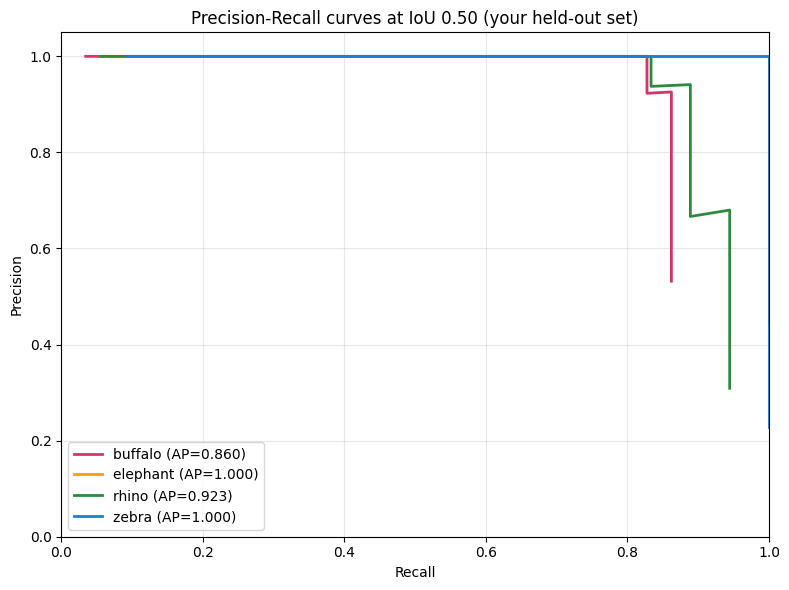


mAP50 (mean over classes) = 0.9457
Per-class AP@0.50:
  buffalo    0.8595
  elephant   1.0000
  rhino      0.9234
  zebra      1.0000


In [6]:
def pr_curve_for_class(cls_id, iou_thr=0.5):
    """Build the precision-recall curve and AP for one class across all images."""
    # Gather (score, is_tp) for every prediction of this class, across all images.
    all_scored = []
    n_gt_total = 0
    for stem in ground_truth:
        cls_gts = [b for c, b in ground_truth[stem] if c == cls_id]
        cls_preds = [(s, b) for c, s, b in predictions.get(stem, []) if c == cls_id]
        matches, n_gt = match_one_image(cls_gts, cls_preds, iou_thr)
        all_scored.extend(matches)
        n_gt_total += n_gt

    if n_gt_total == 0:
        return np.array([]), np.array([]), 0.0

    all_scored.sort(key=lambda p: -p[0])
    tp = np.array([t for _, t in all_scored])
    fp = 1 - tp
    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)
    recalls = tp_cum / n_gt_total
    precisions = tp_cum / np.maximum(tp_cum + fp_cum, 1e-9)

    # All-points interpolation (VOC2010+/COCO): precision envelope, then integrate.
    mrec = np.concatenate([[0.0], recalls, [1.0]])
    mpre = np.concatenate([[0.0], precisions, [0.0]])
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i-1] = max(mpre[i-1], mpre[i])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx+1] - mrec[idx]) * mpre[idx+1])
    return precisions, recalls, ap


# Plot the PR curve for every class.
fig, ax = plt.subplots(figsize=(8, 6))
colours = ["#d6336c", "#f59f00", "#2b8a3e", "#1c7ed6"]
aps = {}
for cls_id, name in enumerate(CLASSES):
    prec, rec, ap = pr_curve_for_class(cls_id, iou_thr=0.5)
    aps[name] = ap
    if len(rec) > 0:
        ax.plot(rec, prec, color=colours[cls_id], label=f"{name} (AP={ap:.3f})", linewidth=2)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.set_title("Precision-Recall curves at IoU 0.50 (your held-out set)")
ax.legend(loc="lower left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

mAP50 = np.mean([a for a in aps.values()])
print(f"\nmAP50 (mean over classes) = {mAP50:.4f}")
print("Per-class AP@0.50:")
for name, ap in aps.items():
    print(f"  {name:<10s} {ap:.4f}")

**Reading the curve.** A curve hugging the top-right (high precision maintained even at high recall) is excellent. A curve that drops steeply means the model can only achieve high recall by accepting many false positives. The **area under the curve is the Average Precision (AP)**, and the mean of the per-class APs is **mAP50** — the same number Ultralytics reported in Lab 7, but now you've computed it yourself and know exactly what it means.

Cross-check: the mAP50 you just computed should be in the same ballpark as what Ultralytics reports if you run `model.val()` on this same set. It won't match to the third decimal — implementations differ slightly in interpolation and edge cases — but it should be close. Small discrepancies are normal; large ones mean a bug in your ground-truth labels or class ordering.

## 7. Why there is no ROC curve for detection

You may have met the **ROC curve** (Receiver Operating Characteristic) in a classification context — it plots the true-positive rate against the false-positive rate as a threshold varies, and the area under it (AUC) is a popular single-number score. A natural question: why didn't we draw one here?

**Because ROC needs a false-positive *rate*, and that needs a count of true negatives — which object detection does not have.**

Recall the definitions:

- True-positive rate (recall) = TP / (TP + FN) — fine, we have TP and FN.
- False-positive rate = FP / (FP + **TN**) — requires **true negatives**.

In classification, a true negative is clear: a negative example correctly classified as negative. In **detection**, what would a true negative be? A location in the image where there is no object and the model correctly drew no box? But there are effectively *infinitely many* such locations — every possible box position and size that doesn't contain an object. You cannot count them, so FP-rate is undefined, so ROC cannot be constructed.

**The precision-recall curve is the correct tool for detection** precisely because it never refers to true negatives. Precision uses TP and FP; recall uses TP and FN. Both are well-defined without ever counting correct absences. This is why the entire detection literature — PASCAL VOC, COCO, every YOLO paper — reports mAP (area under PR) and never ROC/AUC.

> **The takeaway for your career:** ROC is not a universal evaluation tool. It belongs to problems with a finite, countable set of negatives (most classification). When someone asks for 'the ROC curve' of a detector, the correct response is to explain why the PR curve is what they want instead.

## 8. mAP across IoU thresholds — the 50-95 story

Everything so far used IoU ≥ 0.5 to decide a match. But 0.5 is lenient — a box overlapping its target by just half counts as correct. For applications where the *precise* box matters (measuring, cropping, counting in dense scenes) we want stricter localisation.

**mAP50-95** averages the mAP computed at IoU thresholds 0.50, 0.55, 0.60, …, 0.95 (ten thresholds). It rewards models that localise tightly, not just approximately. A model with high mAP50 but low mAP50-95 finds the objects but draws sloppy boxes.

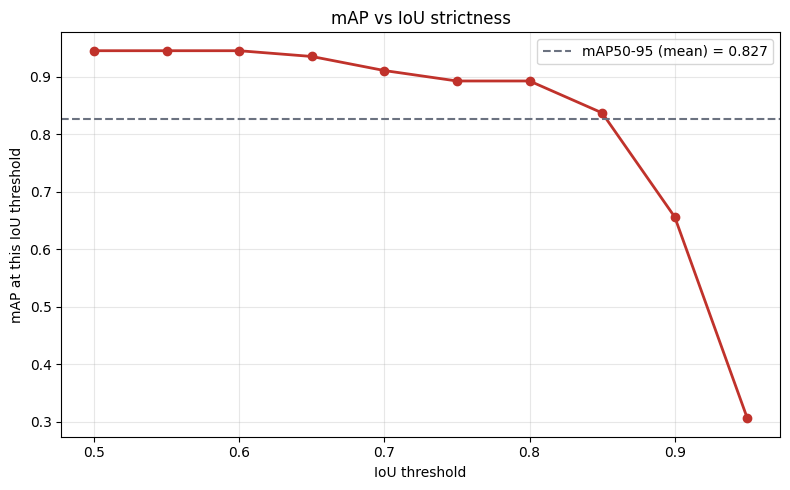

mAP50    = 0.9457
mAP50-95 = 0.8270

The drop from mAP50 to mAP50-95 (+0.119) tells you how
much of your performance is loose localisation that fails under stricter IoU.


In [7]:
iou_thresholds = np.arange(0.50, 1.00, 0.05)   # 0.50, 0.55, ..., 0.95
map_per_iou = []

for iou_t in iou_thresholds:
    aps_at_t = []
    for cls_id in range(len(CLASSES)):
        _, _, ap = pr_curve_for_class(cls_id, iou_thr=iou_t)
        aps_at_t.append(ap)
    map_per_iou.append(np.mean(aps_at_t))

map_per_iou = np.array(map_per_iou)
mAP50_95 = map_per_iou.mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(iou_thresholds, map_per_iou, marker="o", color="#c0322b", linewidth=2)
ax.set_xlabel("IoU threshold"); ax.set_ylabel("mAP at this IoU threshold")
ax.set_title("mAP vs IoU strictness"); ax.grid(alpha=0.3)
ax.axhline(mAP50_95, color="#6b7280", linestyle="--", label=f"mAP50-95 (mean) = {mAP50_95:.3f}")
ax.legend()
plt.tight_layout(); plt.show()

print(f"mAP50    = {map_per_iou[0]:.4f}")
print(f"mAP50-95 = {mAP50_95:.4f}")
print(f"\nThe drop from mAP50 to mAP50-95 ({map_per_iou[0]-mAP50_95:+.3f}) tells you how")
print("much of your performance is loose localisation that fails under stricter IoU.")

## 9. The honest comparison — held-out vs training-split

Here is the moment of truth. Go back to your Lab 7 output (or rerun `model.val(split='test')` there) and note the **mAP50 and mAP50-95 it reported on the in-distribution test split**. Enter them below and compare against what you just measured on your independent ground-truth set.

In [8]:
# EDIT THESE with the numbers Lab 7 reported on its test split.
lab7_map50 = 0.9795      # <-- put your Lab 7 test-split mAP50 here
lab7_map50_95 = 0.8576   # <-- put your Lab 7 test-split mAP50-95 here

holdout_map50 = map_per_iou[0]
holdout_map50_95 = mAP50_95

print(f"{'Metric':<12s} {'Lab7 test split':>16s} {'Your held-out set':>18s} {'Gap':>8s}")
print("-" * 56)
print(f"{'mAP50':<12s} {lab7_map50:>16.3f} {holdout_map50:>18.3f} {holdout_map50-lab7_map50:>+8.3f}")
print(f"{'mAP50-95':<12s} {lab7_map50_95:>16.3f} {holdout_map50_95:>18.3f} {holdout_map50_95-lab7_map50_95:>+8.3f}")
print()
if holdout_map50 < lab7_map50 - 0.05:
    print("As expected: performance dropped on the independent set. That gap is the")
    print("generalisation gap — the honest estimate of how your model behaves in the wild.")
else:
    print("Little or no drop — either your held-out set is similar to training, or your")
    print("model generalises well. Inspect the failure cases (Section 10) to be sure.")

Metric        Lab7 test split  Your held-out set      Gap
--------------------------------------------------------
mAP50                   0.980              0.946   -0.034
mAP50-95                0.858              0.827   -0.031

Little or no drop — either your held-out set is similar to training, or your
model generalises well. Inspect the failure cases (Section 10) to be sure.


## 10. Error analysis — where, and how, does it fail?

A single mAP number tells you *how much* the model fails, not *how* or *where*. Diagnosis needs disaggregation. We'll do three cuts: per-class, by object size, and by error type.

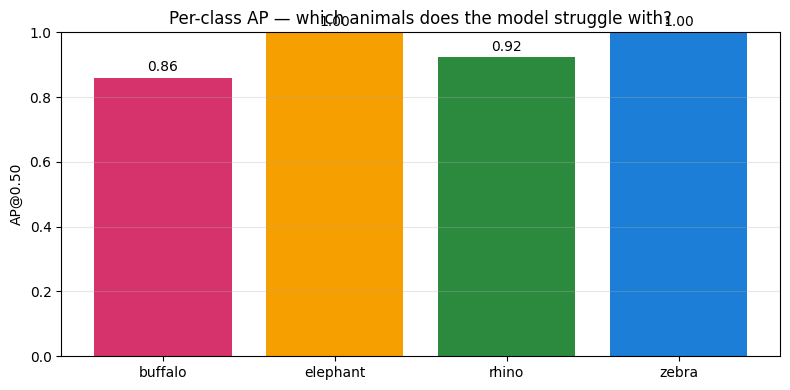

Class      AP@0.50   GT boxes
  buffalo    0.860   29
  elephant   1.000   17
  rhino      0.923   18
  zebra      1.000   11


In [9]:
# --- Per-class AP (already computed in section 6) ---
fig, ax = plt.subplots(figsize=(8, 4))
names = list(aps.keys())
vals = [aps[n] for n in names]
bars = ax.bar(names, vals, color=colours)
ax.set_ylabel("AP@0.50"); ax.set_ylim(0, 1)
ax.set_title("Per-class AP — which animals does the model struggle with?")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# Tie performance to data availability — classes with few ground-truth boxes
# usually score worse simply because there's less to learn from and measure on.
print("Class      AP@0.50   GT boxes")
for name in names:
    cid = CLASSES.index(name)
    print(f"  {name:<8s} {aps[name]:>7.3f}   {gt_per_class[cid]}")

In [10]:
# --- Performance by object size ---
# Define small/medium/large by ground-truth box area as a fraction of image area.
# (COCO uses absolute pixel areas; fractions are more robust across image sizes.)
def box_area_fraction(stem, box):
    with Image.open(HOLDOUT_IMAGES / f"{stem}.jpg") as im:
        W, H = im.size
    x1, y1, x2, y2 = box
    return ((x2-x1) * (y2-y1)) / (W * H)

size_bins = {"small (<2%)": [], "medium (2-10%)": [], "large (>10%)": []}

# For each ground-truth box, was it detected (matched by any pred at conf>=0.25, IoU>=0.5)?
for stem in ground_truth:
    for cls_id, gbox in ground_truth[stem]:
        frac = box_area_fraction(stem, gbox)
        cls_preds = [(s, b) for c, s, b in predictions.get(stem, [])
                     if c == cls_id and s >= 0.25]
        detected = any(iou_xyxy(gbox, b) >= 0.5 for _, b in cls_preds)
        bin_name = ("small (<2%)" if frac < 0.02
                    else "medium (2-10%)" if frac < 0.10
                    else "large (>10%)")
        size_bins[bin_name].append(detected)

print("Recall by object size (fraction of ground-truth boxes detected):")
for bin_name, hits in size_bins.items():
    if hits:
        print(f"  {bin_name:<16s} {np.mean(hits):.2%}  ({len(hits)} boxes)")
    else:
        print(f"  {bin_name:<16s} no boxes in this bin")
print("\nDetectors almost always do worst on small objects. If yours does too,")
print("that's a clue for Lab 9 — more small-object examples, higher imgsz, etc.")

Recall by object size (fraction of ground-truth boxes detected):
  small (<2%)      60.00%  (15 boxes)
  medium (2-10%)   91.30%  (23 boxes)
  large (>10%)     100.00%  (37 boxes)

Detectors almost always do worst on small objects. If yours does too,
that's a clue for Lab 9 — more small-object examples, higher imgsz, etc.


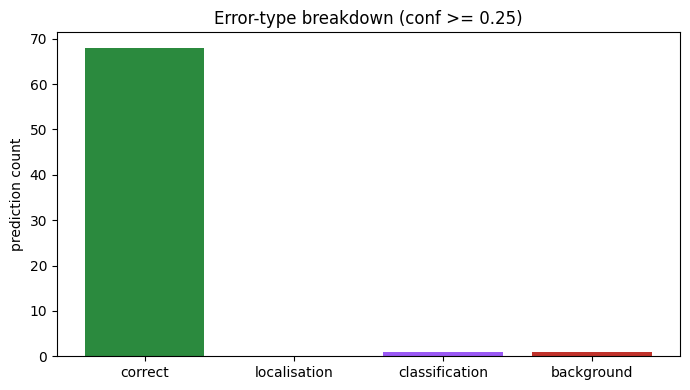

{'correct': 68, 'localisation': 0, 'classification': 1, 'background': 1}

This tells you what KIND of mistakes dominate:
  localisation  -> boxes roughly right but not tight (tune anchors/imgsz)
  classification-> right place wrong label (classes look alike; more data)
  background    -> hallucinated boxes on empty regions (more negatives, higher conf)


In [11]:
# --- Error-type breakdown at conf>=0.25 ---
# Classify each prediction as: correct (TP), localisation error (right class,
# 0.1<=IoU<0.5 with a GT of that class), classification error (IoU>=0.5 with a
# GT but of a DIFFERENT class), or background (IoU<0.1 with any GT).
err = {"correct": 0, "localisation": 0, "classification": 0, "background": 0}

for stem in ground_truth:
    gts = ground_truth[stem]
    for cls_id, score, pbox in predictions.get(stem, []):
        if score < 0.25:
            continue
        # best IoU against any GT, and against same-class GT
        best_any = max([iou_xyxy(pbox, gb) for _, gb in gts], default=0.0)
        best_same = max([iou_xyxy(pbox, gb) for c, gb in gts if c == cls_id], default=0.0)
        best_other = max([iou_xyxy(pbox, gb) for c, gb in gts if c != cls_id], default=0.0)
        if best_same >= 0.5:
            err["correct"] += 1
        elif 0.1 <= best_same < 0.5:
            err["localisation"] += 1
        elif best_other >= 0.5:
            err["classification"] += 1
        else:
            err["background"] += 1

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(err.keys(), err.values(), color=["#2b8a3e", "#f59f00", "#9a59f4", "#c0322b"])
ax.set_ylabel("prediction count"); ax.set_title("Error-type breakdown (conf >= 0.25)")
plt.tight_layout(); plt.show()
print(err)
print("\nThis tells you what KIND of mistakes dominate:")
print("  localisation  -> boxes roughly right but not tight (tune anchors/imgsz)")
print("  classification-> right place wrong label (classes look alike; more data)")
print("  background    -> hallucinated boxes on empty regions (more negatives, higher conf)")

### Look at the actual failures

Numbers point you at the problem; *images* show it to you. Render the held-out images with both ground truth (solid) and predictions (dashed) so you can see exactly what went wrong.

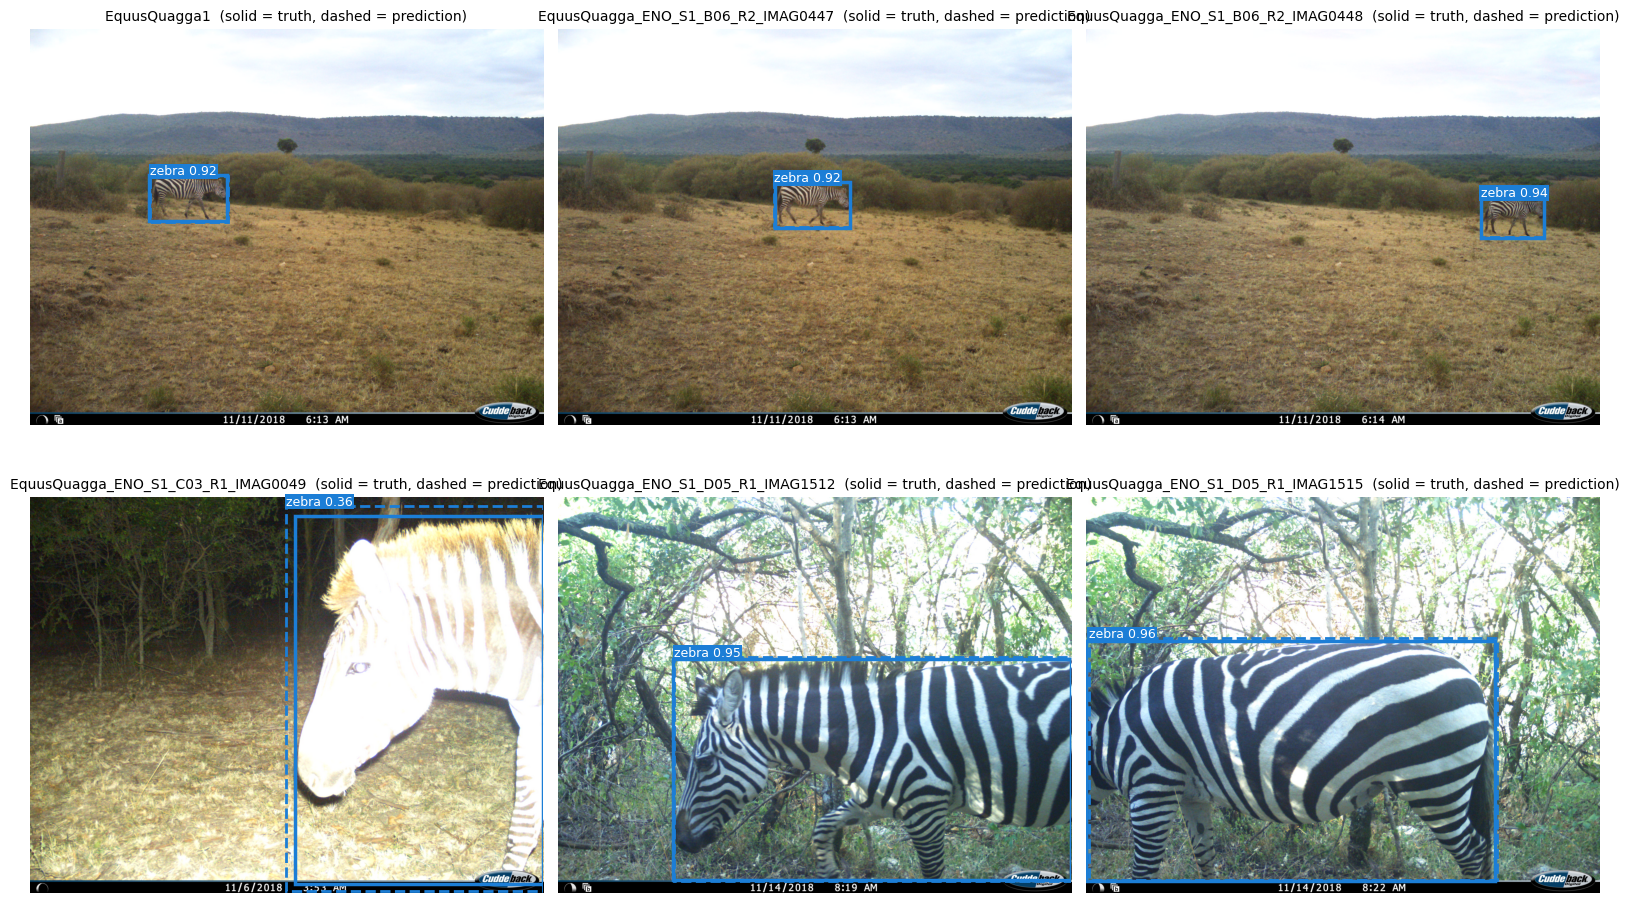

In [12]:
import matplotlib.patches as patches

def show_image_eval(stem, conf_thr=0.25, ax=None):
    img = Image.open(HOLDOUT_IMAGES / f"{stem}.jpg")
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img); ax.axis("off")
    # ground truth — solid
    for cls_id, b in ground_truth[stem]:
        ax.add_patch(patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                     linewidth=2.5, edgecolor=colours[cls_id], facecolor="none"))
    # predictions — dashed
    for cls_id, score, b in predictions.get(stem, []):
        if score < conf_thr:
            continue
        ax.add_patch(patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                     linewidth=2, edgecolor=colours[cls_id], facecolor="none", linestyle="--"))
        ax.text(b[0], b[1]-3, f"{CLASSES[cls_id]} {score:.2f}", color="white", fontsize=9,
                bbox=dict(boxstyle="square,pad=0.1", facecolor=colours[cls_id], edgecolor="none"))
    ax.set_title(f"{stem}  (solid = truth, dashed = prediction)", fontsize=10)

# Show the first 6 held-out images.
n_show = min(6, len(image_files))
fig, axes = plt.subplots((n_show+2)//3, 3, figsize=(16, 5*((n_show+2)//3)))
axes = np.array(axes).flatten()
for ax, p in zip(axes, image_files[:n_show]):
    show_image_eval(p.stem, ax=ax)
for ax in axes[n_show:]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

## 11. Confidence intervals — how much do you trust these numbers?

Here's a question almost nobody asks but everybody should: **how precise is your mAP estimate?** If you measured mAP50 = 0.62 on 30 images, is the 'true' value 0.62? Or could it be anywhere from 0.50 to 0.74?

A single number on a small test set has substantial uncertainty, and reporting it without error bars is one of the most common sins in applied ML. We quantify it with the **bootstrap**: resample the test images with replacement many times, recompute mAP each time, and look at the spread of results. The middle 95% of that spread is a 95% confidence interval.

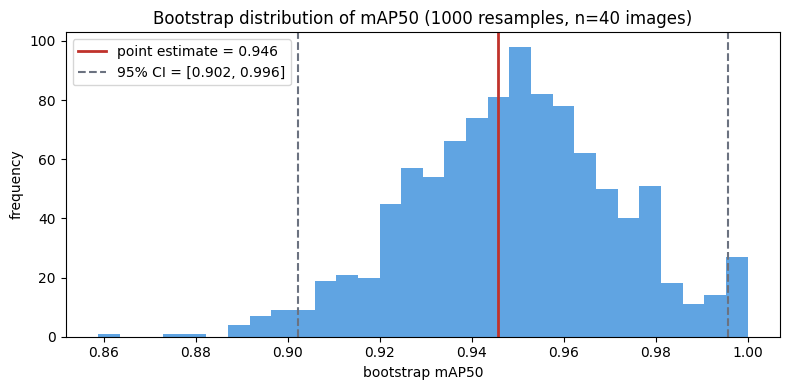

mAP50 = 0.946, 95% CI [0.902, 0.996], width 0.093

That interval width is your honesty check. On 40 images it is probably wide.
To report a tighter number, you need a bigger test set — there is no shortcut.


In [13]:
def map50_on_subset(stems, iou_thr=0.5):
    """Compute mAP50 using only the given image stems."""
    aps_local = []
    for cls_id in range(len(CLASSES)):
        all_scored = []
        n_gt_total = 0
        for stem in stems:
            cls_gts = [b for c, b in ground_truth[stem] if c == cls_id]
            cls_preds = [(s, b) for c, s, b in predictions.get(stem, []) if c == cls_id]
            matches, n_gt = match_one_image(cls_gts, cls_preds, iou_thr)
            all_scored.extend(matches)
            n_gt_total += n_gt
        if n_gt_total == 0:
            continue
        all_scored.sort(key=lambda p: -p[0])
        tp = np.array([t for _, t in all_scored]); fp = 1 - tp
        tpc, fpc = np.cumsum(tp), np.cumsum(fp)
        rec = tpc / n_gt_total
        prec = tpc / np.maximum(tpc + fpc, 1e-9)
        mrec = np.concatenate([[0.0], rec, [1.0]]); mpre = np.concatenate([[0.0], prec, [0.0]])
        for i in range(len(mpre)-1, 0, -1):
            mpre[i-1] = max(mpre[i-1], mpre[i])
        idx = np.where(mrec[1:] != mrec[:-1])[0]
        aps_local.append(np.sum((mrec[idx+1]-mrec[idx]) * mpre[idx+1]))
    return np.mean(aps_local) if aps_local else 0.0


rng = np.random.default_rng(7144)
stems = list(ground_truth.keys())
n = len(stems)
B = 1000
boot = np.empty(B)
for b in range(B):
    sample = list(rng.choice(stems, size=n, replace=True))
    boot[b] = map50_on_subset(sample)

point = map50_on_subset(stems)
lo, hi = np.percentile(boot, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot, bins=30, color="#1c7ed6", alpha=0.7)
ax.axvline(point, color="#c0322b", linewidth=2, label=f"point estimate = {point:.3f}")
ax.axvline(lo, color="#6b7280", linestyle="--", label=f"95% CI = [{lo:.3f}, {hi:.3f}]")
ax.axvline(hi, color="#6b7280", linestyle="--")
ax.set_xlabel("bootstrap mAP50"); ax.set_ylabel("frequency")
ax.set_title(f"Bootstrap distribution of mAP50 ({B} resamples, n={n} images)")
ax.legend(); plt.tight_layout(); plt.show()

print(f"mAP50 = {point:.3f}, 95% CI [{lo:.3f}, {hi:.3f}], width {hi-lo:.3f}")
print(f"\nThat interval width is your honesty check. On {n} images it is probably wide.")
print("To report a tighter number, you need a bigger test set — there is no shortcut.")

## 12. Exercise 1 — operating-point selection

Your PR curve shows the trade-off; now make a *decision*. Suppose this detector will run a wildlife-monitoring camera where **missing an animal is much worse than a false alarm** (a missed rhino is a lost data point — potentially a serious one, given rhinos are a critically endangered species for which every sighting matters; a false alarm just gets filtered by a human later).

1. Using `evaluate_at_threshold`, sweep the confidence threshold from 0.05 to 0.9 in steps of 0.05.
2. Plot precision and recall against threshold on the same axes.
3. Choose the threshold you would deploy for this 'recall matters most' scenario, and state the precision you'd pay for it.
4. Now suppose the priority flips (false alarms are expensive, misses are tolerable). Which threshold now? Write 3–4 sentences justifying both choices.

In [ ]:
# Your code for Exercise 1 here.


*Your chosen thresholds and justification:*



## 13. Exercise 2 — the cross-check

We computed mAP from scratch. Ultralytics can compute it too. Build a small `data.yaml` pointing at your held-out set (images + labels in the train/val/test structure from Lab 6) and run:

```python
metrics = model.val(data="holdout.yaml", split="test", iou=0.5)
print(metrics.box.map50, metrics.box.map)
```

1. Compare Ultralytics' mAP50 against your hand-computed value from Section 6.
2. They will be *close* but probably not identical. Give two concrete reasons why two correct mAP implementations can disagree slightly (think: interpolation method, how ties in confidence are broken, how images with no ground truth are handled).
3. Which do you trust more, and why? (Trick question — reflect on what 'trust' means when both are valid conventions.)

In [ ]:
# Your code for Exercise 2 here.


*Your comparison and explanation:*



## 14. Exercise 3 — open-ended (pick one)

**Option A — Expand the test set and watch the CI tighten.** Add another 30 images to your held-out set (60+ total), re-annotate, rerun. Does the bootstrap confidence interval narrow as predicted? Quantify by how much. Plot CI width against test-set size if you're keen.

**Option B — Stratified evaluation.** Split your held-out set into two subgroups that differ in some controlled way — e.g. 'easy' (animal large, centred, well-lit) vs 'hard' (small, occluded, poor light). Compute mAP separately for each. How large is the gap? This is how you'd discover, for instance, that your model is fine in daylight but useless at dusk.

**Option C — Annotator-agreement effect on metrics.** Have a classmate independently annotate the *same* 10 held-out images. Compute your model's mAP against your labels, then against theirs. How much does the 'ground truth' itself move the metric? This exposes a humbling truth: your mAP is only as certain as your labels, and labels are not perfectly objective.

In [ ]:
# Your code for Exercise 3 (Option A, B, or C) here.


*Which option, and what you found:*



---

## 15. Reflection questions

**Q1.** In one or two sentences, explain the difference between an in-distribution test split and an independent ground-truth set, and why the latter gives a more honest performance estimate.

**Q2.** Explain, in your own words, why object detection has no ROC curve. What property would a problem need for ROC to be well-defined?

**Q3.** Your model scores mAP50 = 0.80 but mAP50-95 = 0.45. In plain English, what does this pattern tell you about the model's behaviour? Name one concrete change you'd try to close the gap.

**Q4.** A colleague reports 'our detector gets 0.91 mAP' with no other detail. List three follow-up questions you'd ask before believing the number is meaningful.

**Q5.** You measured a wide bootstrap confidence interval on your mAP. A stakeholder wants 'a single number for the report'. How do you respond responsibly — what do you report, and what do you say about it?

*Your answers:*

**A1.** 

**A2.** 

**A3.** 

**A4.** 

**A5.** 

---

## What's next

You now have an honest, disaggregated picture of your model's weaknesses: which classes it struggles with, what sizes it misses, what kinds of errors dominate, and how uncertain the numbers are. **Lab 9 closes the loop** — you'll take these diagnosed weaknesses and systematically attack them (more and better-targeted data, augmentation aimed at your specific failure modes, hyperparameter changes, perhaps active learning), then re-run *this* lab's evaluation to *prove* whether your changes actually helped. That cycle — measure, diagnose, intervene, re-measure — is the scientific method applied to machine learning, and it's the most important professional habit this module can give you.

Before leaving today, make sure:

- [ ] You sourced and annotated at least 30 real held-out images
- [ ] You completed Exercises 1, 2, and 3
- [ ] You answered the reflection questions
- [ ] You recorded your held-out mAP50 and mAP50-95 **with their confidence interval** — you'll compare against them in Lab 9
- [ ] Your notebook runs top to bottom without errors